# Alpha Vantage API : Top Favorite Company Stock Project
API Documentation: https://www.alphavantage.co/documentation/#intelligence

## Acquisition

In [48]:
# imported libraries
import requests
import pandas as pd
import numpy as np
import time
import os

# visual libs
import matplotlib.pyplot as plt
import seaborn as sns


# custom import to bring in api_key and not display
import config

In [6]:
api_key = config.ALPHA_VANTAGE_API_KEY

In [7]:
# per the alpha vantage api; documentation is well written and fairly easy to follow
# replace the "demo" apikey below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=QQQ&apikey=api_key'
r = requests.get(url)
data = r.json()

print(data)

{'Meta Data': {'1. Information': 'Daily Prices (open, high, low, close) and Volumes', '2. Symbol': 'QQQ', '3. Last Refreshed': '2023-10-03', '4. Output Size': 'Compact', '5. Time Zone': 'US/Eastern'}, 'Time Series (Daily)': {'2023-10-03': {'1. open': '358.7800', '2. high': '361.0100', '3. low': '353.2750', '4. close': '354.9200', '5. volume': '60478489'}, '2023-10-02': {'1. open': '358.5400', '2. high': '362.6800', '3. low': '357.9200', '4. close': '361.2600', '5. volume': '51625054'}, '2023-09-29': {'1. open': '361.5400', '2. high': '362.9500', '3. low': '357.0200', '4. close': '358.2700', '5. volume': '64829616'}, '2023-09-28': {'1. open': '354.1100', '2. high': '360.1700', '3. low': '353.2400', '4. close': '358.0100', '5. volume': '56453312'}, '2023-09-27': {'1. open': '355.3800', '2. high': '356.9800', '3. low': '351.3600', '4. close': '355.0400', '5. volume': '56065972'}, '2023-09-26': {'1. open': '356.9900', '2. high': '357.5400', '3. low': '353.2101', '4. close': '354.2100', '5.

### Decided to extract daily information from top diversified stock index funds

In [8]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=QQQ&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'qqq_open', '2. high': 'qqq_high', '3. low': 'qqq_low', '4. close': 'qqq_close', '5. volume': 'qqq_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# checking info of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   qqq_open    6019 non-null   object
 1   qqq_high    6019 non-null   object
 2   qqq_low     6019 non-null   object
 3   qqq_close   6019 non-null   object
 4   qqq_volume  6019 non-null   object
dtypes: object(5)
memory usage: 282.1+ KB


### Noted all data returned when queried comes back as a object

In [9]:
df.head()

,qqq_open,qqq_high,qqq_low,qqq_close,qqq_volume
2023-10-03,358.7800,361.0100,353.2750,354.9200,60478489
2023-10-02,358.5400,362.6800,357.9200,361.2600,51625054
2023-09-29,361.5400,362.9500,357.0200,358.2700,64829616
2023-09-28,354.1100,360.1700,353.2400,358.0100,56453312
2023-09-27,355.3800,356.9800,351.3600,355.0400,56065972


In [10]:
df.index.dtype

dtype('<M8[ns]')

In [11]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=DIA&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'dia_open', '2. high': 'dia_high', '3. low': 'dia_low', '4. close': 'dia_close', '5. volume': 'dia_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# Print the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   dia_open    6019 non-null   object
 1   dia_high    6019 non-null   object
 2   dia_low     6019 non-null   object
 3   dia_close   6019 non-null   object
 4   dia_volume  6019 non-null   object
dtypes: object(5)
memory usage: 282.1+ KB


In [12]:
df.head()

,dia_open,dia_high,dia_low,dia_close,dia_volume
2023-10-03,332.8400,333.8800,329.0401,329.9800,4871058
2023-10-02,334.2900,335.0200,332.0800,334.0900,4192554
2023-09-29,338.7800,338.8300,333.9100,334.9500,3786535
2023-09-28,335.3200,337.6700,334.5700,336.6200,4053596
2023-09-27,336.8800,337.1500,332.9300,335.4300,4442227


In [13]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=SPY&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'spy_open', '2. high': 'spy_high', '3. low': 'spy_low', '4. close': 'spy_close', '5. volume': 'spy_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# Print the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   spy_open    6019 non-null   object
 1   spy_high    6019 non-null   object
 2   spy_low     6019 non-null   object
 3   spy_close   6019 non-null   object
 4   spy_volume  6019 non-null   object
dtypes: object(5)
memory usage: 282.1+ KB


In [14]:
df.head()

,spy_open,spy_high,spy_low,spy_close,spy_volume
2023-10-03,425.0600,427.3729,420.1800,421.5900,103760607
2023-10-02,426.6200,428.6000,424.4600,427.3100,83798599
2023-09-29,431.6700,431.8500,425.9100,427.4800,115111319
2023-09-28,425.4800,430.2499,424.8700,428.5200,92258308
2023-09-27,427.0900,427.6700,422.2900,426.0500,104705847


In [15]:

# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&outputsize=full&apikey=demo

# Sample ticker traded in UK - London Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSCO.LON&outputsize=full&apikey=demo

# Sample ticker traded in Canada - Toronto Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=SHOP.TRT&outputsize=full&apikey=demo

# Sample ticker traded in Canada - Toronto Venture Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=GPV.TRV&outputsize=full&apikey=demo

# Sample ticker traded in Germany - XETRA
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=MBG.DEX&outputsize=full&apikey=demo

# Sample ticker traded in India - BSE
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=RELIANCE.BSE&outputsize=full&apikey=demo

# Sample ticker traded in China - Shanghai Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=600104.SHH&outputsize=full&apikey=demo

# Sample ticker traded in China - Shenzhen Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=000002.SHZ&outputsize=full&apikey=demo

### I can see all efts, stocks, etc. are all organized from 1999 to current date so i should be able to just input stock symbols for company I would like to query with the same time frames.

* favorite companies  

Nvidia Corporation: The stock symbol for Nvidia is NVDA.
    
Apple Inc.: The stock symbol for Apple is AAPL.    

Advanced Micro Devices, Inc. (AMD): The stock symbol for AMD is AMD

* oversea stocks

iShares China Large-Cap ETF: FXI  

Shares MSCI India ETF: INDA  

iShares MSCI United Kingdom ETF: EWU

## Above were some ideas scanned and interested in

### I am checking each of my favorite companies data to see if they would all have similar date range of records

In [16]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=NVDA&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'nvda_open', '2. high': 'nvda_high', '3. low': 'nvda_low', '4. close': 'nvda_close', '5. volume': 'nvda_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# checking info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nvda_open    6019 non-null   object
 1   nvda_high    6019 non-null   object
 2   nvda_low     6019 non-null   object
 3   nvda_close   6019 non-null   object
 4   nvda_volume  6019 non-null   object
dtypes: object(5)
memory usage: 282.1+ KB


In [17]:
df.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume
2023-10-03,448.0800,451.3000,432.4600,435.1700,47084954
2023-10-02,440.3000,451.7500,438.6100,447.8200,43329821
2023-09-29,438.2700,441.4400,433.0694,434.9900,39782993
2023-09-28,424.6000,434.4631,421.1500,430.8900,42466279
2023-09-27,423.3000,428.7200,416.2901,424.6800,44493520


In [19]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AAPL&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'aapl_open', '2. high': 'aapl_high', '3. low': 'aapl_low', '4. close': 'aapl_close', '5. volume': 'aapl_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# Print the DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   aapl_open    6019 non-null   object
 1   aapl_high    6019 non-null   object
 2   aapl_low     6019 non-null   object
 3   aapl_close   6019 non-null   object
 4   aapl_volume  6019 non-null   object
dtypes: object(5)
memory usage: 282.1+ KB


In [20]:
df.head()

,aapl_open,aapl_high,aapl_low,aapl_close,aapl_volume
2023-10-03,172.2550,173.6300,170.8200,172.4000,49594613
2023-10-02,171.2200,174.3000,170.9300,173.7500,52164535
2023-09-29,172.0200,173.0700,170.3410,171.2100,51861083
2023-09-28,169.3400,172.0300,167.6200,170.6900,56294419
2023-09-27,172.6200,173.0400,169.0500,170.4300,66921808


In [21]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AMD&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'amd_open', '2. high': 'amd_high', '3. low': 'amd_low', '4. close': 'amd_close', '5. volume': 'amd_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# Print the DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   amd_open    6019 non-null   object
 1   amd_high    6019 non-null   object
 2   amd_low     6019 non-null   object
 3   amd_close   6019 non-null   object
 4   amd_volume  6019 non-null   object
dtypes: object(5)
memory usage: 282.1+ KB


  ## Fortunately all the data was organized well and the follwiong code block is a function that uses recommended syntax. The url has been adjusted to retuen all listed symbols specified and then return all df for the stock data concatenated.

In [38]:
# Function to retrieve and process data for a stock symbol
def get_stock_data(symbol, api_key):
    url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=full&apikey={api_key}'
    r = requests.get(url)
    data = r.json()
    
    daily_data = data['Time Series (Daily)']
    
    df = pd.DataFrame(daily_data).T  # Transpose to have dates as index
    df = df.rename(columns={'1. open': f'{symbol}_open', '2. high': f'{symbol}_high', '3. low': f'{symbol}_low', '4. close': f'{symbol}_close', '5. volume': f'{symbol}_volume'})
    df.index = pd.to_datetime(df.index) # set the index for timestamps to dattime values; originally object.
    
    return df

# Get data for NVDA, AAPL, and AMD
nvda_data = get_stock_data('NVDA', api_key)
aapl_data = get_stock_data('AAPL', api_key)
amd_data = get_stock_data('AMD', api_key)

# Concatenate the dataframes into a single dataframe
all_data = pd.concat([nvda_data, aapl_data, amd_data], axis=1)

# Print the concatenated dataframe
all_data.head()

,NVDA_open,NVDA_high,NVDA_low,NVDA_close,NVDA_volume,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AAPL_volume,AMD_open,AMD_high,AMD_low,AMD_close,AMD_volume
2023-10-03,448.0800,451.3000,432.4600,435.1700,47084954,172.2550,173.6300,170.8200,172.4000,49594613,101.7963,103.2900,99.1700,100.0800,48116980
2023-10-02,440.3000,451.7500,438.6100,447.8200,43329821,171.2200,174.3000,170.9300,173.7500,52164535,102.2100,103.7100,101.7000,103.2700,45118574
2023-09-29,438.2700,441.4400,433.0694,434.9900,39782993,172.0200,173.0700,170.3410,171.2100,51861083,104.6900,104.9400,102.5600,102.8200,56078641
2023-09-28,424.6000,434.4631,421.1500,430.8900,42466279,169.3400,172.0300,167.6200,170.6900,56294419,97.9400,104.2000,97.7600,102.7600,72542056
2023-09-27,423.3000,428.7200,416.2901,424.6800,44493520,172.6200,173.0400,169.0500,170.4300,66921808,96.8200,99.2300,96.3500,98.0700,51261502


In [23]:
df = all_data

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NVDA_open    6019 non-null   object
 1   NVDA_high    6019 non-null   object
 2   NVDA_low     6019 non-null   object
 3   NVDA_close   6019 non-null   object
 4   NVDA_volume  6019 non-null   object
 5   AAPL_open    6019 non-null   object
 6   AAPL_high    6019 non-null   object
 7   AAPL_low     6019 non-null   object
 8   AAPL_close   6019 non-null   object
 9   AAPL_volume  6019 non-null   object
 10  AMD_open     6019 non-null   object
 11  AMD_high     6019 non-null   object
 12  AMD_low      6019 non-null   object
 13  AMD_close    6019 non-null   object
 14  AMD_volume   6019 non-null   object
dtypes: object(15)
memory usage: 752.4+ KB


## Now that i have combined my data I can review the information and clean the dataset for ease of use

## below are some other functions i was going to implement, but decided to use my favorite companies

In [27]:
# # Function to retrieve and process data for a stock symbol
# def get_diversified_stock_index_funds_data(symbol, api_key):
#     url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=full&apikey={api_key}'
#     r = requests.get(url)
#     data = r.json()
    
#     daily_data = data['Time Series (Daily)'] 
    
#     df = pd.DataFrame(daily_data).T  # Transpose to have dates as index
#     df = df.rename(columns={'1. open': f'{symbol}_open', '2. high': f'{symbol}_high', '3. low': f'{symbol}_low', '4. close': f'{symbol}_close', '5. volume': f'{symbol}_volume'})
#     df.index = pd.to_datetime(df.index)
    
#     return df

# # Get data for SPY, DIA, and QQQ
# spy_data = get_stock_data('SPY', api_key)
# dia_data = get_stock_data('DIA', api_key)
# qqq_data = get_stock_data('QQQ', api_key)

# # Concatenate the dataframes into a single dataframe
# dsif_data = pd.concat([spy_data, dia_data, qqq_data], axis=1)

# # Print the concatenated dataframe
# dsif_data.head()

In [ ]:
# import requests
# import pandas as pd

# # Function to retrieve and process data for an ETF symbol
# def get_etf_data(symbol, api_key):
#     url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=full&apikey={api_key}'
#     r = requests.get(url)
#     data = r.json()
    
#     daily_data = data['Time Series (Daily)'] 
    
#     df = pd.DataFrame(daily_data).T  # Transpose to have dates as index
#     df = df.rename(columns={'1. open': f'{symbol}_open', '2. high': f'{symbol}_high', '3. low': f'{symbol}_low', '4. close': f'{symbol}_close', '5. volume': f'{symbol}_volume'})
#     df.index = pd.to_datetime(df.index)
    
#     return df

# # Replace "YOUR_API_KEY" with your actual API key
# api_key = 'CDJ0WTJ22LPVEIXL'

# # Get data for FXI, INDA, and EWU
# mchi_data = get_etf_data('MCHI', api_key)
# inda_data = get_etf_data('INDA', api_key)
# midd_data = get_etf_data('MIDD', api_key)

# # Concatenate the dataframes into a single dataframe
# all_etf_data = pd.concat([mchi_data, inda_data, midd_data], axis=1)

# # Print the concatenated dataframe
# all_etf_data.head()

# Prepare   
  

## I need to convert the data into float/int values  

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nvda_open    6019 non-null   float64
 1   nvda_high    6019 non-null   float64
 2   nvda_low     6019 non-null   float64
 3   nvda_close   6019 non-null   float64
 4   nvda_volume  6019 non-null   int64  
 5   aapl_open    6019 non-null   float64
 6   aapl_high    6019 non-null   float64
 7   aapl_low     6019 non-null   float64
 8   aapl_close   6019 non-null   float64
 9   aapl_volume  6019 non-null   int64  
 10  amd_open     6019 non-null   float64
 11  amd_high     6019 non-null   float64
 12  amd_low      6019 non-null   float64
 13  amd_close    6019 non-null   float64
 14  amd_volume   6019 non-null   int64  
dtypes: float64(12), int64(3)
memory usage: 752.4 KB


## As previously inspected; there is no null values and counts match up below as well

In [29]:
df.describe().T

,count,unique,top,freq
NVDA_open,6019,4273,12.5600,9
NVDA_high,6019,4346,36.7500,12
NVDA_low,6019,4378,14.3800,10
NVDA_close,6019,4491,12.6500,7
NVDA_volume,6019,5989,3093600,2
AAPL_open,6019,5265,19.0600,6
AAPL_high,6019,5159,15.0000,8
AAPL_low,6019,5248,14.0000,9
AAPL_close,6019,5299,15.0000,6
AAPL_volume,6019,5997,6968900,2


In [30]:
df = df.apply(pd.to_numeric)

In [40]:
# all columns are now numeric volume
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nvda_open    6019 non-null   float64
 1   nvda_high    6019 non-null   float64
 2   nvda_low     6019 non-null   float64
 3   nvda_close   6019 non-null   float64
 4   nvda_volume  6019 non-null   int64  
 5   aapl_open    6019 non-null   float64
 6   aapl_high    6019 non-null   float64
 7   aapl_low     6019 non-null   float64
 8   aapl_close   6019 non-null   float64
 9   aapl_volume  6019 non-null   int64  
 10  amd_open     6019 non-null   float64
 11  amd_high     6019 non-null   float64
 12  amd_low      6019 non-null   float64
 13  amd_close    6019 non-null   float64
 14  amd_volume   6019 non-null   int64  
dtypes: float64(12), int64(3)
memory usage: 752.4 KB


## I read that volume should be an integer and turning into a float presents no advantage to analysis of data

## Our dataset is comprised of 6,019 observations and 15 columns

In [32]:
df.shape

(6019, 15)

## Here I decided to make the column names lowercase and add underscores to make the data column names more pythonic.

In [33]:
# cleaned up columns names
df.columns = [col.lower() for col in df.columns]
df.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,aapl_open,aapl_high,aapl_low,aapl_close,aapl_volume,amd_open,amd_high,amd_low,amd_close,amd_volume
2023-10-03,448.08,451.3000,432.4600,435.17,47084954,172.255,173.63,170.820,172.40,49594613,101.7963,103.29,99.17,100.08,48116980
2023-10-02,440.30,451.7500,438.6100,447.82,43329821,171.220,174.30,170.930,173.75,52164535,102.2100,103.71,101.70,103.27,45118574
2023-09-29,438.27,441.4400,433.0694,434.99,39782993,172.020,173.07,170.341,171.21,51861083,104.6900,104.94,102.56,102.82,56078641
2023-09-28,424.60,434.4631,421.1500,430.89,42466279,169.340,172.03,167.620,170.69,56294419,97.9400,104.20,97.76,102.76,72542056
2023-09-27,423.30,428.7200,416.2901,424.68,44493520,172.620,173.04,169.050,170.43,66921808,96.8200,99.23,96.35,98.07,51261502


In [35]:
# returning date range of data
print('Date Range:', df.index.min(), 'to', df.index.max())
print('Shape:', df.shape)

Date Range: 1999-11-01 00:00:00 to 2023-10-03 00:00:00
Shape: (6019, 15)


## after checking the date range to ensure my data had a time range usable for analysis, I now am going to view at the distribution of the data retrieved.

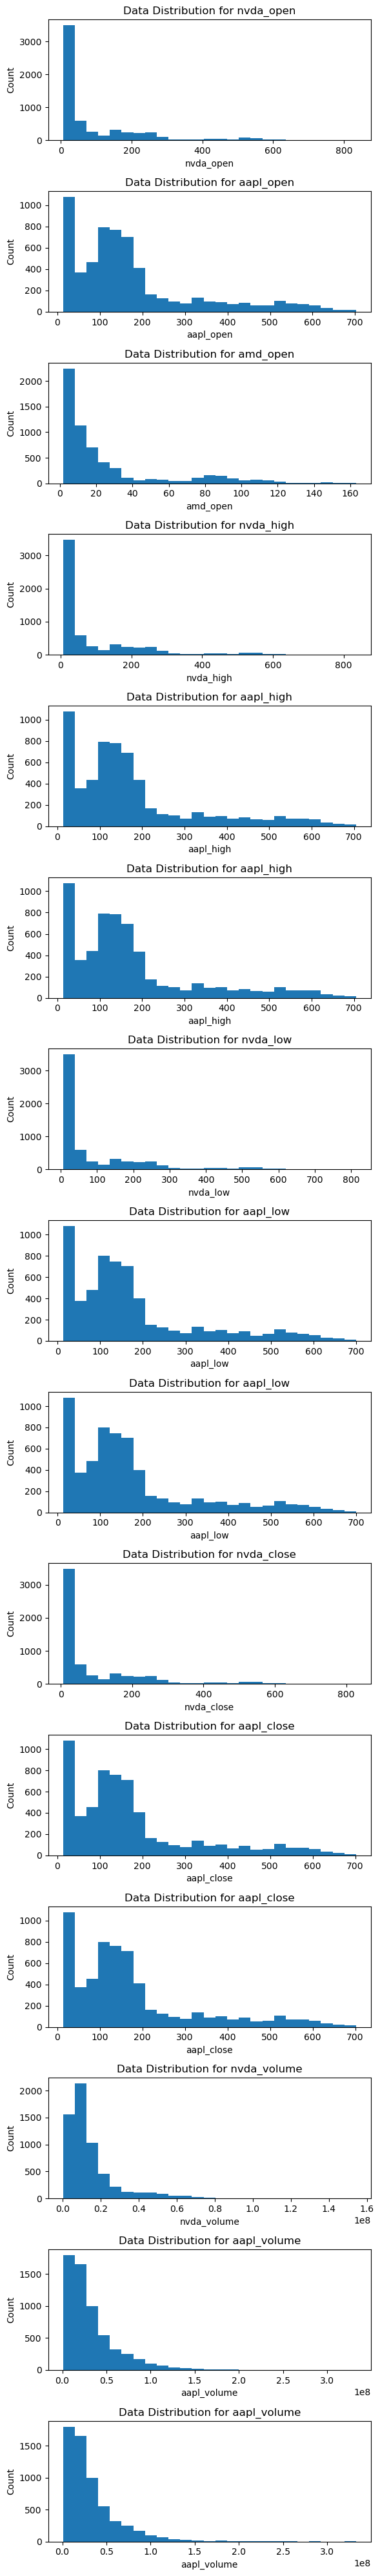

In [41]:
# Select a subset of columns for visualization
selected_columns = ['nvda_open', 'aapl_open', 'amd_open',
                    'nvda_high', 'aapl_high', 'aapl_high',
                    'nvda_low', 'aapl_low', 'aapl_low',
                    'nvda_close', 'aapl_close', 'aapl_close',
                    'nvda_volume', 'aapl_volume', 'aapl_volume',]

# Create subplots for each column
fig, axes = plt.subplots(nrows=len(selected_columns), figsize=(6, 40))

for i, column in enumerate(selected_columns):
    axes[i].hist(df[column], bins=25)  # You can adjust the number of bins as needed
    axes[i].set_title(f'Data Distribution for {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


## After viewing the data using visualization tools and binning the data to see a clearer distribution. I can determine that the data has a normal distribution.

# Explore

## I will now create categorical columns for exploration (day_of_week, month)

In [42]:
df['month'] = df.index.month_name()
df['day_of_week'] = df.index.day_name()

In [51]:
df.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,aapl_open,aapl_high,aapl_low,aapl_close,aapl_volume,amd_open,amd_high,amd_low,amd_close,amd_volume,month,day_of_week
2023-10-03,448.08,451.3000,432.4600,435.17,47084954,172.255,173.63,170.820,172.40,49594613,101.7963,103.29,99.17,100.08,48116980,October,Tuesday
2023-10-02,440.30,451.7500,438.6100,447.82,43329821,171.220,174.30,170.930,173.75,52164535,102.2100,103.71,101.70,103.27,45118574,October,Monday
2023-09-29,438.27,441.4400,433.0694,434.99,39782993,172.020,173.07,170.341,171.21,51861083,104.6900,104.94,102.56,102.82,56078641,September,Friday
2023-09-28,424.60,434.4631,421.1500,430.89,42466279,169.340,172.03,167.620,170.69,56294419,97.9400,104.20,97.76,102.76,72542056,September,Thursday
2023-09-27,423.30,428.7200,416.2901,424.68,44493520,172.620,173.04,169.050,170.43,66921808,96.8200,99.23,96.35,98.07,51261502,September,Wednesday


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-10-03 to 1999-11-01
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nvda_open    6019 non-null   float64
 1   nvda_high    6019 non-null   float64
 2   nvda_low     6019 non-null   float64
 3   nvda_close   6019 non-null   float64
 4   nvda_volume  6019 non-null   int64  
 5   aapl_open    6019 non-null   float64
 6   aapl_high    6019 non-null   float64
 7   aapl_low     6019 non-null   float64
 8   aapl_close   6019 non-null   float64
 9   aapl_volume  6019 non-null   int64  
 10  amd_open     6019 non-null   float64
 11  amd_high     6019 non-null   float64
 12  amd_low      6019 non-null   float64
 13  amd_close    6019 non-null   float64
 14  amd_volume   6019 non-null   int64  
 15  month        6019 non-null   object 
 16  day_of_week  6019 non-null   object 
dtypes: float64(12), int64(3), object(2)
memory usage: 846.4+ KB


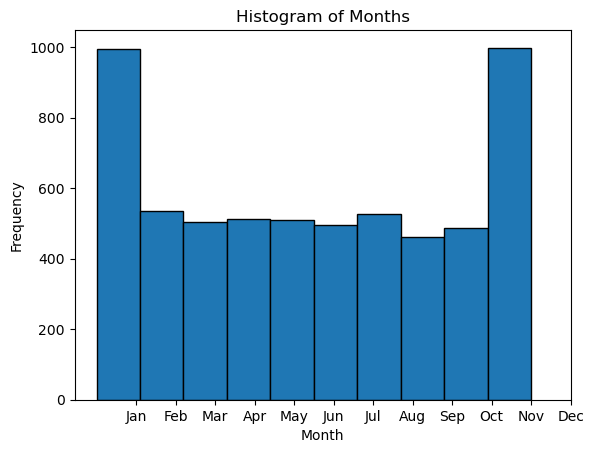

In [103]:
plt.hist(df['month'], ec='black')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Histogram of Months')

# Define custom labels for the ticks
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Set the custom labels for the x-axis ticks
plt.xticks(range(1, 13), month_labels)

plt.show()

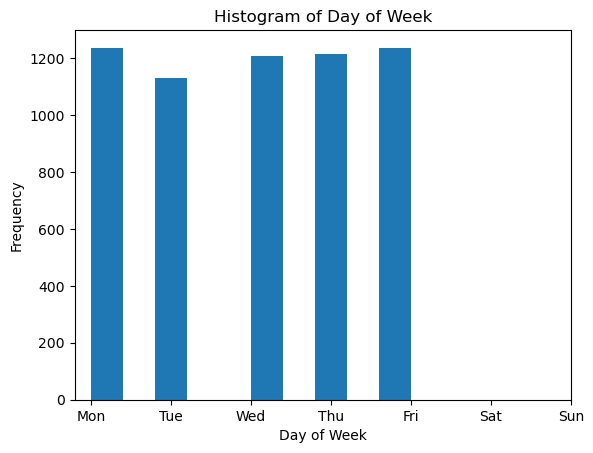

In [100]:
plt.hist(df['day_of_week'])
plt.xlabel('Day of Week')
plt.ylabel('Frequency')
plt.title('Histogram of Day of Week')

# Define custom labels for the ticks
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Set the custom labels for the x-axis ticks
plt.xticks(range(7), day_labels)

plt.show()

## My categorical data displays a higher frequency for stocks active during the week highlighting closed market on the weekends. Also months nov-dec seem to have no activity?

## now i'm going to look at the data of the stock company I selected from

Text(0.5, 1.0, 'Open versus volume (amd)')

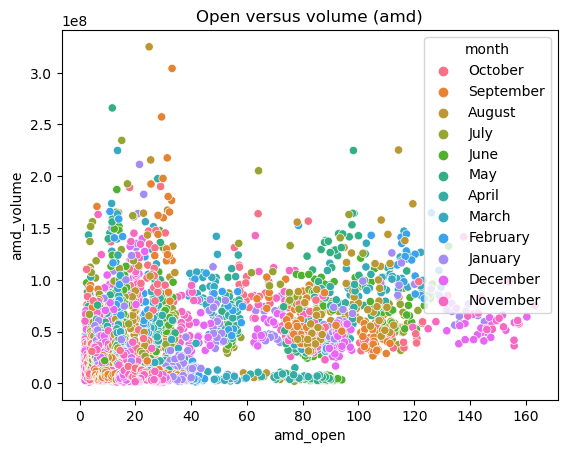

In [110]:
sns.scatterplot(data = df, x='amd_open', y='amd_volume', hue='month')
plt.title('Open versus volume (amd)')

Text(0.5, 1.0, 'Open versus volume (NVIDIA)')

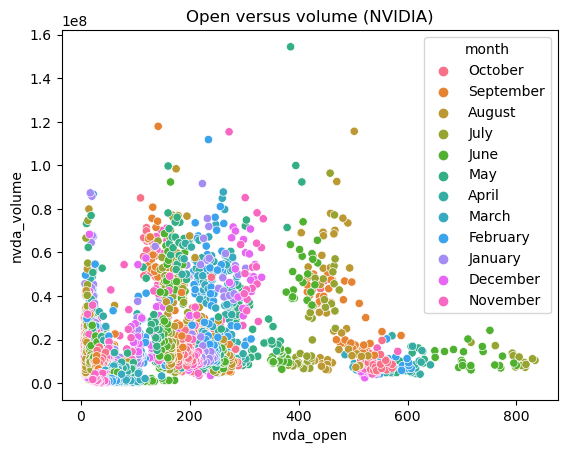

In [108]:
sns.scatterplot(data = df, x='nvda_open', y='nvda_volume', hue='month')
plt.title('Open versus volume (NVIDIA)')

Text(0.5, 1.0, 'Open versus volume (apple)')

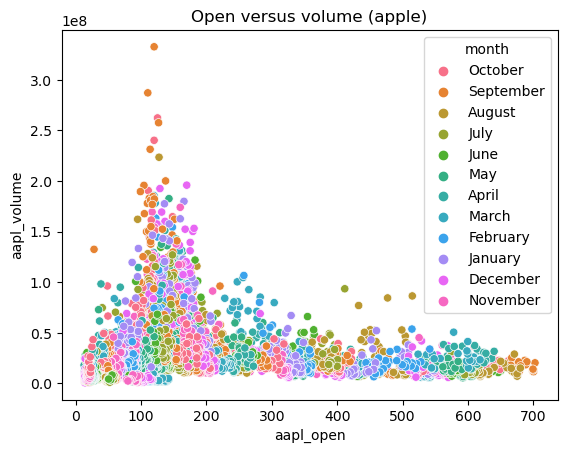

In [109]:
sns.scatterplot(data = df, x='aapl_open', y='aapl_volume', hue='month')
plt.title('Open versus volume (apple)')

## The scatter plots here are very interesting to look at, here we can see comparisons and how these feature are displayed

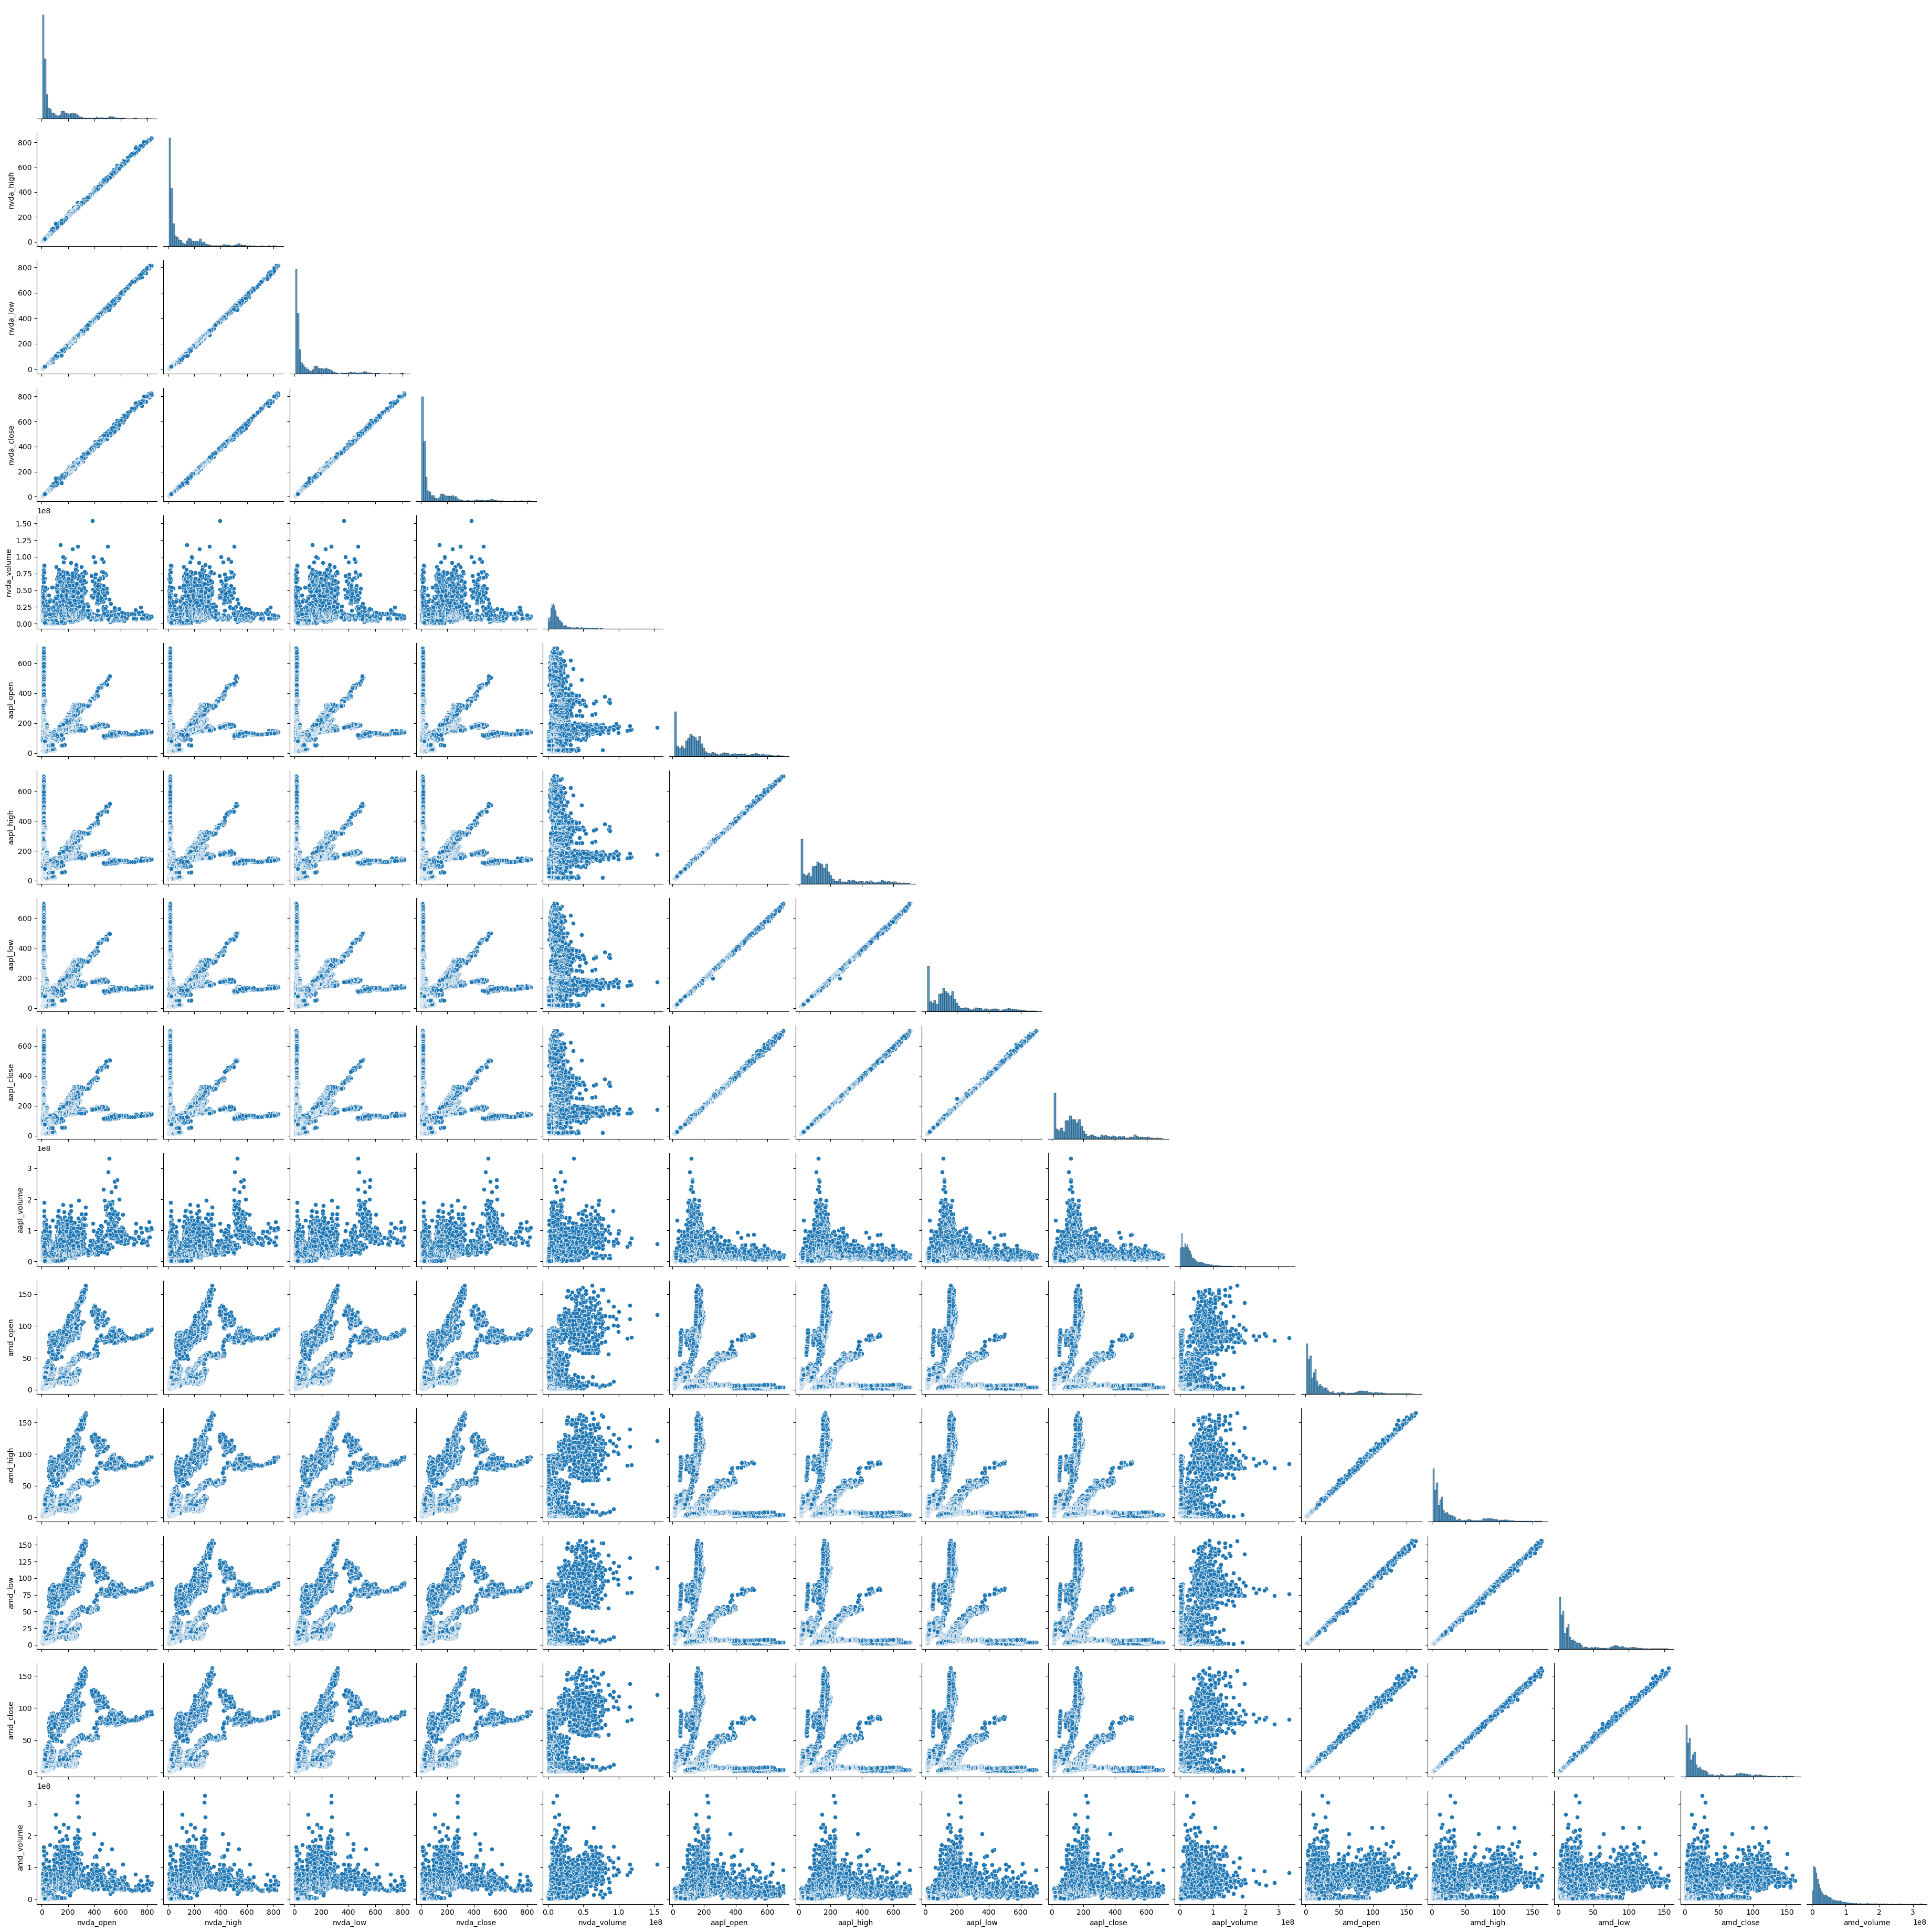

In [127]:
sns.pairplot(df, corner=True)

In [ ]:
## I will continue exploration and=